# GFlowNet for Sequence Generation

Train a GFlowNet to sample sequences with probability proportional to reward: $P(x) \propto R(x)$

In [1]:
import matplotlib.pyplot as plt

from gfn import (
    train,
    TrainingConfig,
    generate_greedy_trajectory,
    ACTIONS_LIST,
    DEFAULT_TARGETS,
    use_preset,
    print_env_info,
    get_env_config,
    EnvConfig,
    set_env_config,
)
from gfn.reward import TargetMatchReward, AlignmentReward
from gfn.visualization import (
    plot_training_curves,
    plot_reward_distribution,
    plot_state_space,
    plot_flow_network,
    print_policy,
)

%matplotlib inline

## 1. Configuration

In [2]:
rna_short = EnvConfig(alphabet=['A', 'U', 'G', 'C'], max_seq_len=4)
set_env_config(rna_short)
print_env_info()

config = TrainingConfig(
    seed=43,
    n_hid_units=32,
    n_episodes=20_000,
    learning_rate=3e-3,
    update_freq=4,
    uniform_backward=True,
)

Environment Configuration:
  Alphabet: ['A', 'U', 'G', 'C']
  Max sequence length: 4
  Timesteps: 5
  Vocab size: 4
  Max actions: 36


In [3]:
target_sequences = [
    ['A', 'U', 'U', 'C'],  # AUUC
    ['A', 'U', 'C', 'C'],  # AUCC
    ['C', 'A', 'C', 'C'],  # CACC
    ['C', 'U', 'A', 'ε'],  # CUA
    ['C', 'C', 'U', 'A'],  # CCUA
    ['C', 'C', 'C', 'A'],  # CCCA
    ['G', 'G', 'G', 'G'],  # Poly-G
    ['A', 'G', 'A', 'A'],  # AGAA
    ['A', 'C', 'G', 'G'],  # ACGG
    ['A', 'A', 'G', 'A'],  # AAGA
    ['U', 'G', 'C', 'C'],  # UGCC
    ['A', 'G', 'G', 'A'],  # AGGA
    ['U', 'U', 'U', 'C'],  # UUUC
]

reward_fn = TargetMatchReward(target_sequences, r_min=0.1)

## 2. Training

In [4]:
result = train(reward_fn, config, verbose=True)

TB Training: 100%|███| 20000/20000 [00:30<00:00, 653.29it/s]


## 3. Training Results

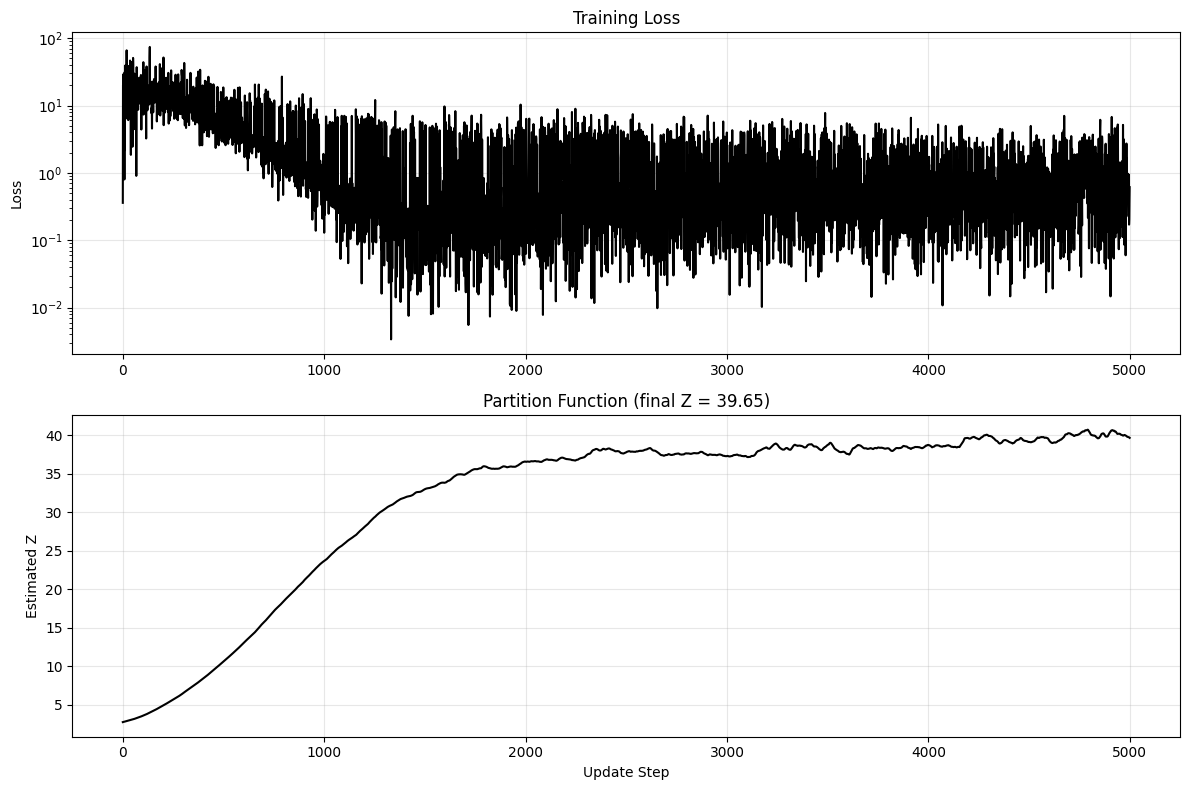


Final Z = 39.65


In [5]:
fig = plot_training_curves(result)
plt.show()

print(f"\nFinal Z = {result.final_Z:.2f}")

In [6]:
plot_reward_distribution(result, reward_fn)


Reward Distribution (20000 samples):
----------------------------------------
  Reward 0.10: 92.6%
  Reward 1.00: 7.4%


## 4. Analysis

In [7]:
trajectory = generate_greedy_trajectory(result.model)

for t, state in enumerate(trajectory):
    seq = ''.join(s for s in state[1] if s != 'ε') or 'ε'
    print(f"  t={t}: {seq}")

  t=0: ε
  t=1: C
  t=2: CC
  t=3: CCA
  t=4: CCCA


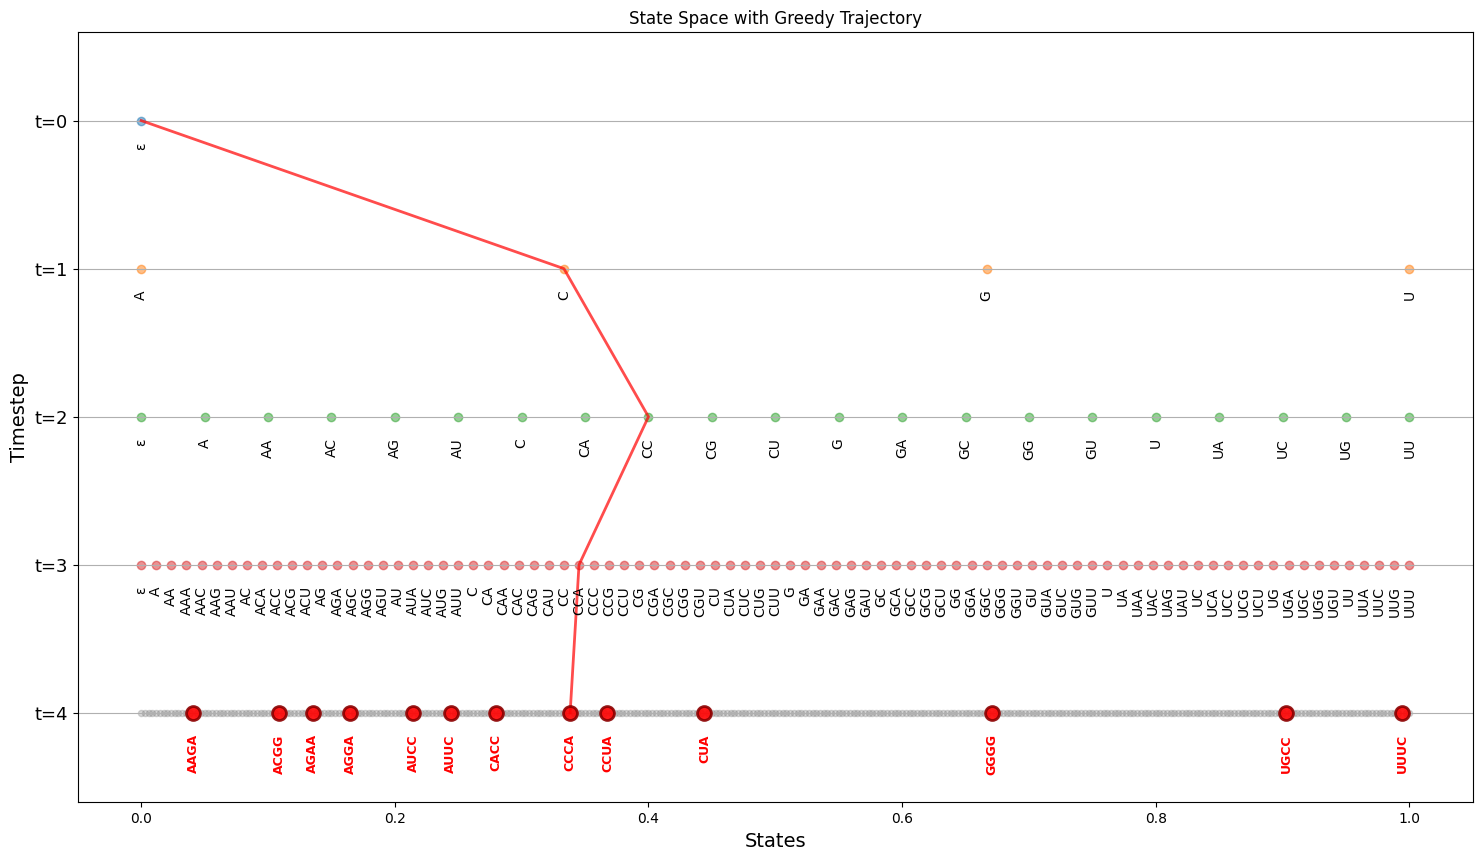

In [8]:
fig = plot_state_space(trajectory=trajectory, target_sequences=target_sequences)
plt.title("State Space with Greedy Trajectory")
plt.show()


Max flow trajectories (greedy traceback):

Trajectory for target 'AUUC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: AUC
  t=4: AUUC

Trajectory for target 'AUCC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: AUC
  t=4: AUCC

Trajectory for target 'CACC':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CAC
  t=4: CACC

Trajectory for target 'CUA':
  t=0: ε
  t=1: U
  t=2: CU
  t=3: CUA
  t=4: CUA

Trajectory for target 'CCUA':
  t=0: ε
  t=1: U
  t=2: CU
  t=3: CUA
  t=4: CCUA

Trajectory for target 'CCCA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CCA
  t=4: CCCA

Trajectory for target 'GGGG':
  t=0: ε
  t=1: G
  t=2: GG
  t=3: GGG
  t=4: GGGG

Trajectory for target 'AGAA':
  t=0: ε
  t=1: A
  t=2: AA
  t=3: AGA
  t=4: AGAA

Trajectory for target 'ACGG':
  t=0: ε
  t=1: G
  t=2: CG
  t=3: ACG
  t=4: ACGG

Trajectory for target 'AAGA':
  t=0: ε
  t=1: A
  t=2: AA
  t=3: AGA
  t=4: AAGA

Trajectory for target 'UGCC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: UGC
  t=4: UGCC

Trajectory for target 'AGGA':
  t=0: ε
  t=1: A
  t=2: A

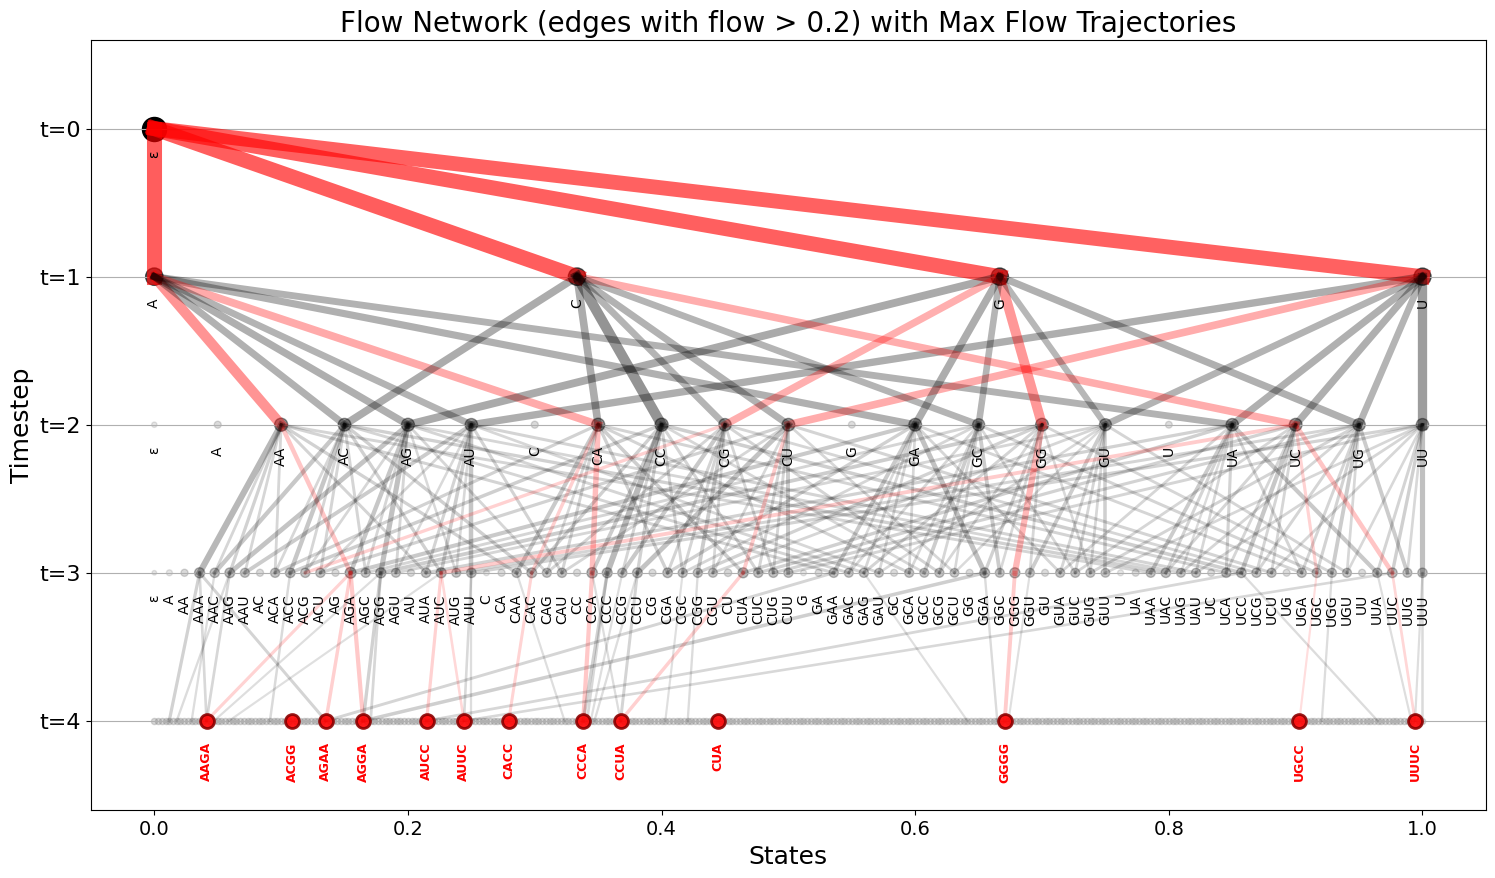

In [9]:
plot_flow_network(
    result.model,
    target_sequences=target_sequences,
    edge_flow_threshold=0.2,
    show_nontarget_terminal_labels=False, 
)
plt.show()

## 5. Policy Inspection

In [10]:
test_states = [
    [0, ['ε', 'ε', 'ε', 'ε']],  # Root state
    [2, ['C', 'C', 'ε', 'ε']],   # Intermediate state
    [3, ['C', 'C', 'A', 'ε']],   # Near terminal
]

for state in test_states:
    print_policy(result.model, state)


Policy for state [0, ['ε', 'ε', 'ε', 'ε']]:
--------------------------------------------------
  ('insert', 0, 'A'): 0.256
  ('insert', 0, 'B'): 0.239
  ('insert', 0, 'C'): 0.248
  ('insert', 1, 'A'): 0.258

Policy for state [2, ['C', 'C', 'ε', 'ε']]:
--------------------------------------------------
  ('insert', 0, 'A'): 0.088
  ('insert', 0, 'B'): 0.093
  ('insert', 0, 'C'): 0.054
  ('insert', 1, 'A'): 0.095
  ('insert', 1, 'B'): 0.082
  ('insert', 1, 'C'): 0.066
  ('insert', 2, 'A'): 0.065
  ('insert', 2, 'B'): 0.106
  ('insert', 2, 'C'): 0.108
  ('insert', 3, 'A'): 0.077
  ('insert', 3, 'B'): 0.062
  ('insert', 3, 'C'): 0.071

Policy for state [3, ['C', 'C', 'A', 'ε']]:
--------------------------------------------------
  ('insert', 0, 'A'): 0.018
  ('insert', 0, 'B'): 0.029
  ('insert', 0, 'C'): 0.029
  ('insert', 1, 'A'): 0.165
  ('insert', 1, 'B'): 0.038
  ('insert', 1, 'C'): 0.028
  ('insert', 2, 'A'): 0.026
  ('insert', 2, 'B'): 0.181
  ('insert', 2, 'C'): 0.026
  ('insert',

In [11]:
print("Last 20 sampled states:")
for state in result.sampled_states[-20:]:
    seq = ''.join(s for s in state[1] if s != 'ε') or 'ε'
    reward = reward_fn(state[1])
    marker = "*" if reward > 0.1 else " "
    print(f"  {marker} {seq}")

Last 20 sampled states:
    ACCU
    UCU
    AAUA
    AUGU
    AG
    GCG
    UCAC
    CUUA
    GGGC
    AGU
    ACCU
  * CCCA
  * AGAA
    GCCA
    UCC
    GAUC
    CA
  * CCUA
    CACA
    AUA


## 6. TB vs DB vs FL-DB Comparison

**TB:** $\mathcal{L}_{TB} = (\log Z + \sum_t \log P_F - \log R - \sum_t \log P_B)^2$

**DB:** $\mathcal{L}_{DB} = \sum_t (\log F(s_t) + \log P_F(a_t|s_t) - \log F(s_{t+1}) - \log P_B(a_t|s_{t+1}))^2$

**FL-DB:** Same as DB but with intermediate rewards $R(s_t \to s_{t+1})$

In [12]:
base_config = dict(
    seed=43,
    n_hid_units=32,
    n_episodes=20_000,
    learning_rate=3e-3,
    update_freq=4,
)

config_tb = TrainingConfig(**base_config, objective="TB")
config_db = TrainingConfig(**base_config, objective="DB")
config_fldb = TrainingConfig(**base_config, objective="FLDB")

# TB & DB use exact match; FL-DB uses alignment-based partial credit
reward_fn_match = TargetMatchReward(target_sequences, r_min=0.1)

target_strings = [''.join(s for s in seq if s != 'ε') for seq in target_sequences]
reward_fn_alignment = AlignmentReward(
    target_sequences=target_strings,
    match_score=1.0,
    mismatch_score=-0.5,
    gap_score=-0.5,
    r_min=0.1
)

In [13]:
result_tb = train(reward_fn_match, config_tb, verbose=True)

TB Training: 100%|███| 20000/20000 [00:30<00:00, 662.79it/s]


In [14]:
result_db = train(reward_fn_match, config_db, verbose=True)

DB Training: 100%|███| 20000/20000 [00:40<00:00, 499.67it/s]


In [15]:
result_fldb = train(reward_fn_alignment, config_fldb, verbose=True)

FL-DB Training: 100%|█| 20000/20000 [00:48<00:00, 409.24it/s


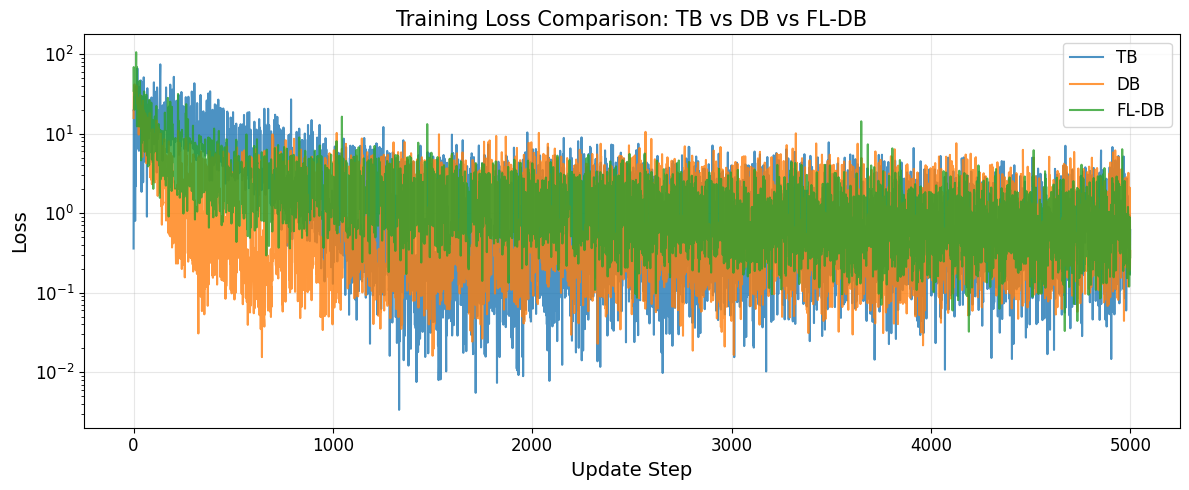

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(result_tb.losses, label='TB', alpha=0.8)
ax.plot(result_db.losses, label='DB', alpha=0.8)
ax.plot(result_fldb.losses, label='FL-DB', alpha=0.8)

ax.set_yscale('log')
ax.set_xlabel('Update Step', fontsize=14)
ax.set_ylabel('Loss', fontsize=14)
ax.set_title('Training Loss Comparison: TB vs DB vs FL-DB', fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

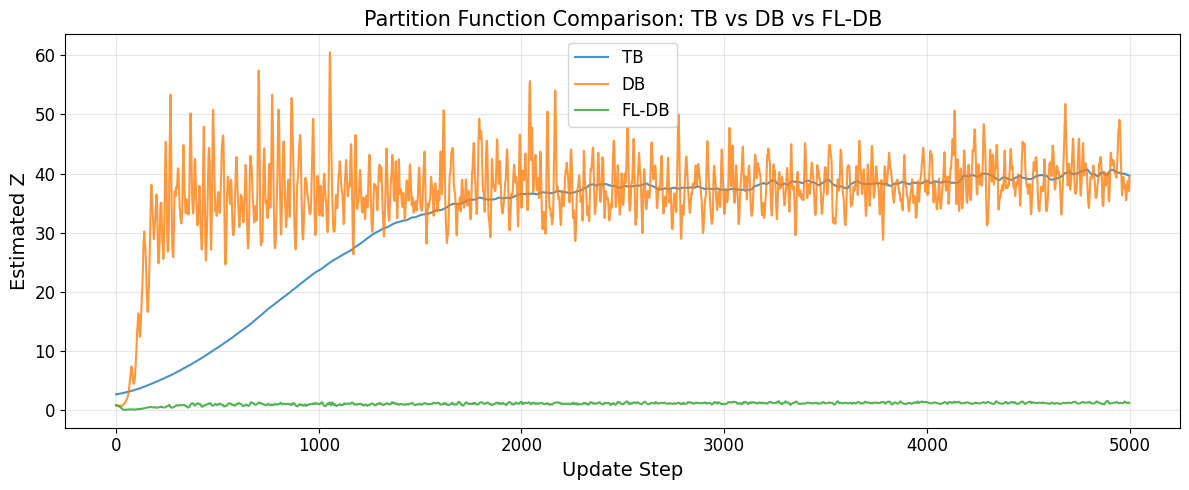

Final Z estimates:
  TB:    39.65
  DB:    39.30
  FL-DB: 1.27


In [17]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(np.exp(result_tb.logZs), label='TB', alpha=0.8)
ax.plot(np.exp(result_db.logZs), label='DB', alpha=0.8)
ax.plot(np.exp(result_fldb.logZs), label='FL-DB', alpha=0.8)

ax.set_xlabel('Update Step', fontsize=14)
ax.set_ylabel('Estimated Z', fontsize=14)
ax.set_title('Partition Function Comparison: TB vs DB vs FL-DB', fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Z estimates:")
print(f"  TB:    {result_tb.final_Z:.2f}")
print(f"  DB:    {result_db.final_Z:.2f}")
print(f"  FL-DB: {result_fldb.final_Z:.2f}")

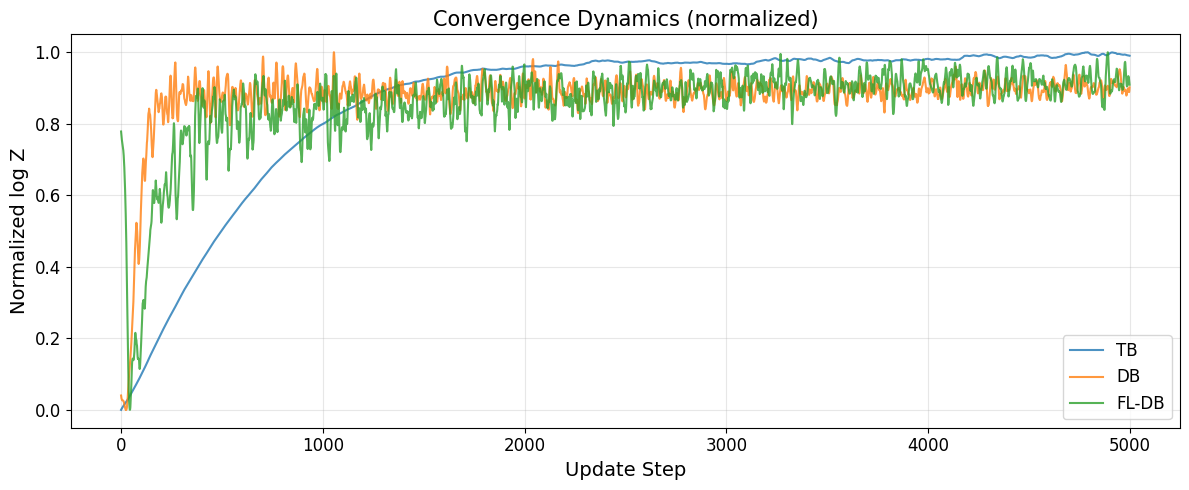

In [18]:
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(normalize(result_tb.logZs), label='TB', alpha=0.8)
ax.plot(normalize(result_db.logZs), label='DB', alpha=0.8)
ax.plot(normalize(result_fldb.logZs), label='FL-DB', alpha=0.8)

ax.set_xlabel('Update Step', fontsize=14)
ax.set_ylabel('Normalized log Z', fontsize=14)
ax.set_title('Convergence Dynamics (normalized)', fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

def get_reward_stats(result, reward_fn):
    rewards = [reward_fn(state[1]) for state in result.sampled_states]
    return {
        'mean': np.mean(rewards),
        'std': np.std(rewards),
        'max': np.max(rewards),
        'target_hit_rate': np.mean([r > 0.5 for r in rewards]) * 100,
    }

stats = {
    'TB': get_reward_stats(result_tb, reward_fn_match),
    'DB': get_reward_stats(result_db, reward_fn_match),
    'FL-DB': get_reward_stats(result_fldb, reward_fn_alignment),
}

print(f"{'Metric':<20} {'TB':>12} {'DB':>12} {'FL-DB':>12}")
print(f"{'Mean Reward':<20} {stats['TB']['mean']:>12.3f} {stats['DB']['mean']:>12.3f} {stats['FL-DB']['mean']:>12.3f}")
print(f"{'Std Reward':<20} {stats['TB']['std']:>12.3f} {stats['DB']['std']:>12.3f} {stats['FL-DB']['std']:>12.3f}")
print(f"{'Max Reward':<20} {stats['TB']['max']:>12.3f} {stats['DB']['max']:>12.3f} {stats['FL-DB']['max']:>12.3f}")
print(f"{'Target Hit Rate':<20} {stats['TB']['target_hit_rate']:>11.1f}% {stats['DB']['target_hit_rate']:>11.1f}% {stats['FL-DB']['target_hit_rate']:>11.1f}%")
print("\nTB/DB use TargetMatchReward, FL-DB uses AlignmentReward")

Metric                         TB           DB        FL-DB
Mean Reward                 0.166        0.154        0.606
Std Reward                  0.235        0.214        0.200
Max Reward                  1.000        1.000        1.000
Target Hit Rate              7.4%         6.0%        62.6%

TB/DB use TargetMatchReward, FL-DB uses AlignmentReward


In [20]:
traj_tb = generate_greedy_trajectory(result_tb.model)
traj_db = generate_greedy_trajectory(result_db.model)
traj_fldb = generate_greedy_trajectory(result_fldb.model)

print(f"{'Step':<6} {'TB':<18} {'DB':<18} {'FL-DB':<18}")
for t in range(len(traj_tb)):
    seq_tb = ''.join(s for s in traj_tb[t][1] if s != 'ε') or 'ε'
    seq_db = ''.join(s for s in traj_db[t][1] if s != 'ε') or 'ε'
    seq_fldb = ''.join(s for s in traj_fldb[t][1] if s != 'ε') or 'ε'
    print(f"t={t:<4} {seq_tb:<18} {seq_db:<18} {seq_fldb:<18}")

Step   TB                 DB                 FL-DB             
t=0    ε                  ε                  ε                 
t=1    C                  U                  C                 
t=2    CC                 UU                 CA                
t=3    CCA                UUC                CUA               
t=4    CCCA               UUUC               CCUA              



Max flow trajectories (greedy traceback):

Trajectory for target 'AUUC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: AUC
  t=4: AUUC

Trajectory for target 'AUCC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: AUC
  t=4: AUCC

Trajectory for target 'CACC':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CAC
  t=4: CACC

Trajectory for target 'CUA':
  t=0: ε
  t=1: U
  t=2: CU
  t=3: CUA
  t=4: CUA

Trajectory for target 'CCUA':
  t=0: ε
  t=1: U
  t=2: CU
  t=3: CUA
  t=4: CCUA

Trajectory for target 'CCCA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CCA
  t=4: CCCA

Trajectory for target 'GGGG':
  t=0: ε
  t=1: G
  t=2: GG
  t=3: GGG
  t=4: GGGG

Trajectory for target 'AGAA':
  t=0: ε
  t=1: A
  t=2: AA
  t=3: AGA
  t=4: AGAA

Trajectory for target 'ACGG':
  t=0: ε
  t=1: G
  t=2: CG
  t=3: ACG
  t=4: ACGG

Trajectory for target 'AAGA':
  t=0: ε
  t=1: A
  t=2: AA
  t=3: AGA
  t=4: AAGA

Trajectory for target 'UGCC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: UGC
  t=4: UGCC

Trajectory for target 'AGGA':
  t=0: ε
  t=1: A
  t=2: A

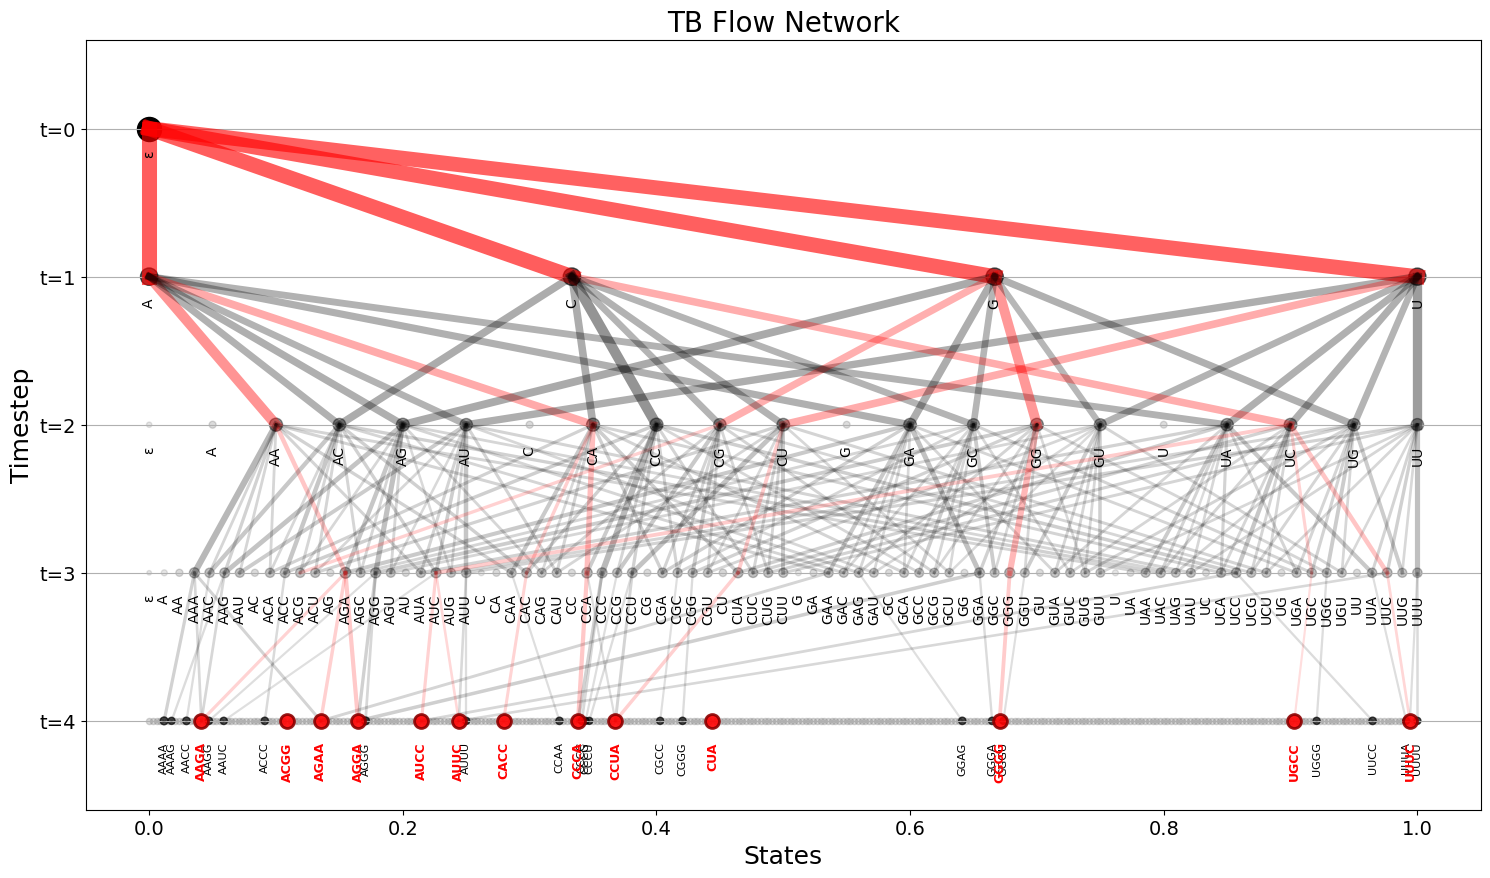

In [21]:
fig_tb = plot_flow_network(
    result_tb.model,
    target_sequences=target_sequences,
    edge_flow_threshold=0.2,
    show_nontarget_terminal_labels=True,
)
plt.title("TB Flow Network", fontsize=20)
plt.xlabel(plt.gca().get_xlabel(), fontsize=18)
plt.ylabel(plt.gca().get_ylabel(), fontsize=18)
plt.tick_params(axis='both', labelsize=14)
fig_tb.savefig("results/flow_network_TB.pdf", bbox_inches='tight')
plt.show()


Max flow trajectories (greedy traceback):

Trajectory for target 'AUUC':
  t=0: ε
  t=1: U
  t=2: AU
  t=3: AUU
  t=4: AUUC

Trajectory for target 'AUCC':
  t=0: ε
  t=1: U
  t=2: AU
  t=3: AUC
  t=4: AUCC

Trajectory for target 'CACC':
  t=0: ε
  t=1: C
  t=2: AC
  t=3: CAC
  t=4: CACC

Trajectory for target 'CUA':
  t=0: ε
  t=1: U
  t=2: CU
  t=3: CUA
  t=4: CUA

Trajectory for target 'CCUA':
  t=0: ε
  t=1: U
  t=2: CU
  t=3: CUA
  t=4: CCUA

Trajectory for target 'CCCA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CCA
  t=4: CCCA

Trajectory for target 'GGGG':
  t=0: ε
  t=1: G
  t=2: GG
  t=3: GGG
  t=4: GGGG

Trajectory for target 'AGAA':
  t=0: ε
  t=1: A
  t=2: AG
  t=3: AGA
  t=4: AGAA

Trajectory for target 'ACGG':
  t=0: ε
  t=1: C
  t=2: CG
  t=3: ACG
  t=4: ACGG

Trajectory for target 'AAGA':
  t=0: ε
  t=1: A
  t=2: AG
  t=3: AAG
  t=4: AAGA

Trajectory for target 'UGCC':
  t=0: ε
  t=1: U
  t=2: UG
  t=3: UGC
  t=4: UGCC

Trajectory for target 'AGGA':
  t=0: ε
  t=1: A
  t=2: A

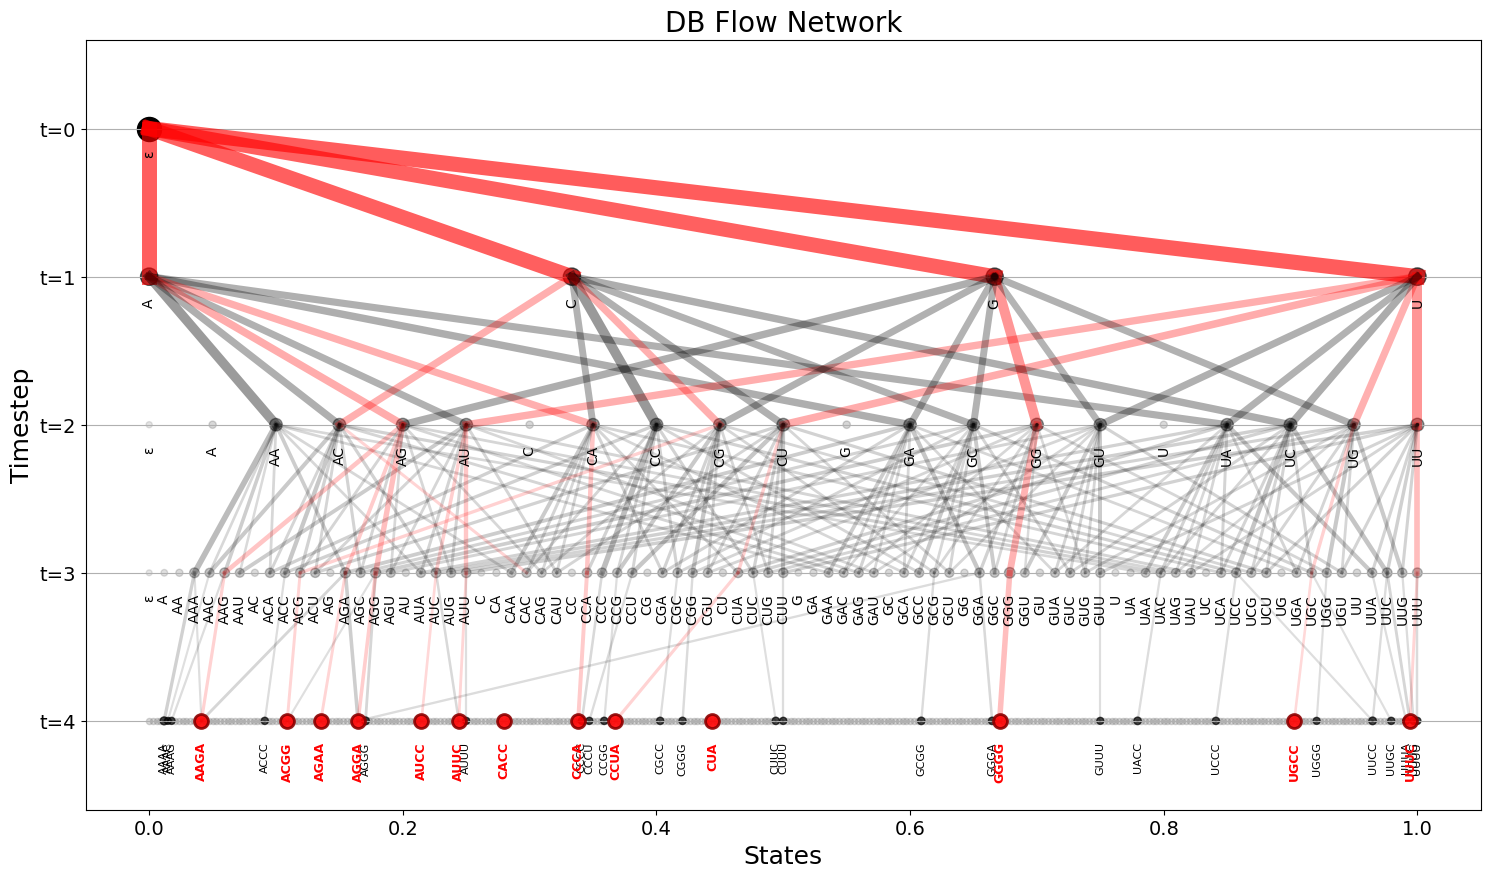

In [22]:
fig_db = plot_flow_network(
    result_db.model,
    target_sequences=target_sequences,
    edge_flow_threshold=0.2,
    show_nontarget_terminal_labels=True,
)
plt.title("DB Flow Network", fontsize=20)
plt.xlabel(plt.gca().get_xlabel(), fontsize=18)
plt.ylabel(plt.gca().get_ylabel(), fontsize=18)
plt.tick_params(axis='both', labelsize=14)
fig_db.savefig("results/flow_network_DB.pdf", bbox_inches='tight')
plt.show()


Max flow trajectories (greedy traceback):

Trajectory for target 'AUUC':
  t=0: ε
  t=1: C
  t=2: AC
  t=3: AUC
  t=4: AUUC

Trajectory for target 'AUCC':
  t=0: ε
  t=1: C
  t=2: AC
  t=3: AUC
  t=4: AUCC

Trajectory for target 'CACC':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CAC
  t=4: CACC

Trajectory for target 'CUA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CUA
  t=4: CUA

Trajectory for target 'CCUA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CUA
  t=4: CCUA

Trajectory for target 'CCCA':
  t=0: ε
  t=1: A
  t=2: CA
  t=3: CCA
  t=4: CCCA

Trajectory for target 'GGGG':
  t=0: ε
  t=1: G
  t=2: GG
  t=3: GGG
  t=4: GGGG

Trajectory for target 'AGAA':
  t=0: ε
  t=1: A
  t=2: AA
  t=3: AGA
  t=4: AGAA

Trajectory for target 'ACGG':
  t=0: ε
  t=1: C
  t=2: CG
  t=3: ACG
  t=4: ACGG

Trajectory for target 'AAGA':
  t=0: ε
  t=1: A
  t=2: AA
  t=3: AGA
  t=4: AAGA

Trajectory for target 'UGCC':
  t=0: ε
  t=1: C
  t=2: UC
  t=3: UCC
  t=4: UGCC

Trajectory for target 'AGGA':
  t=0: ε
  t=1: A
  t=2: A

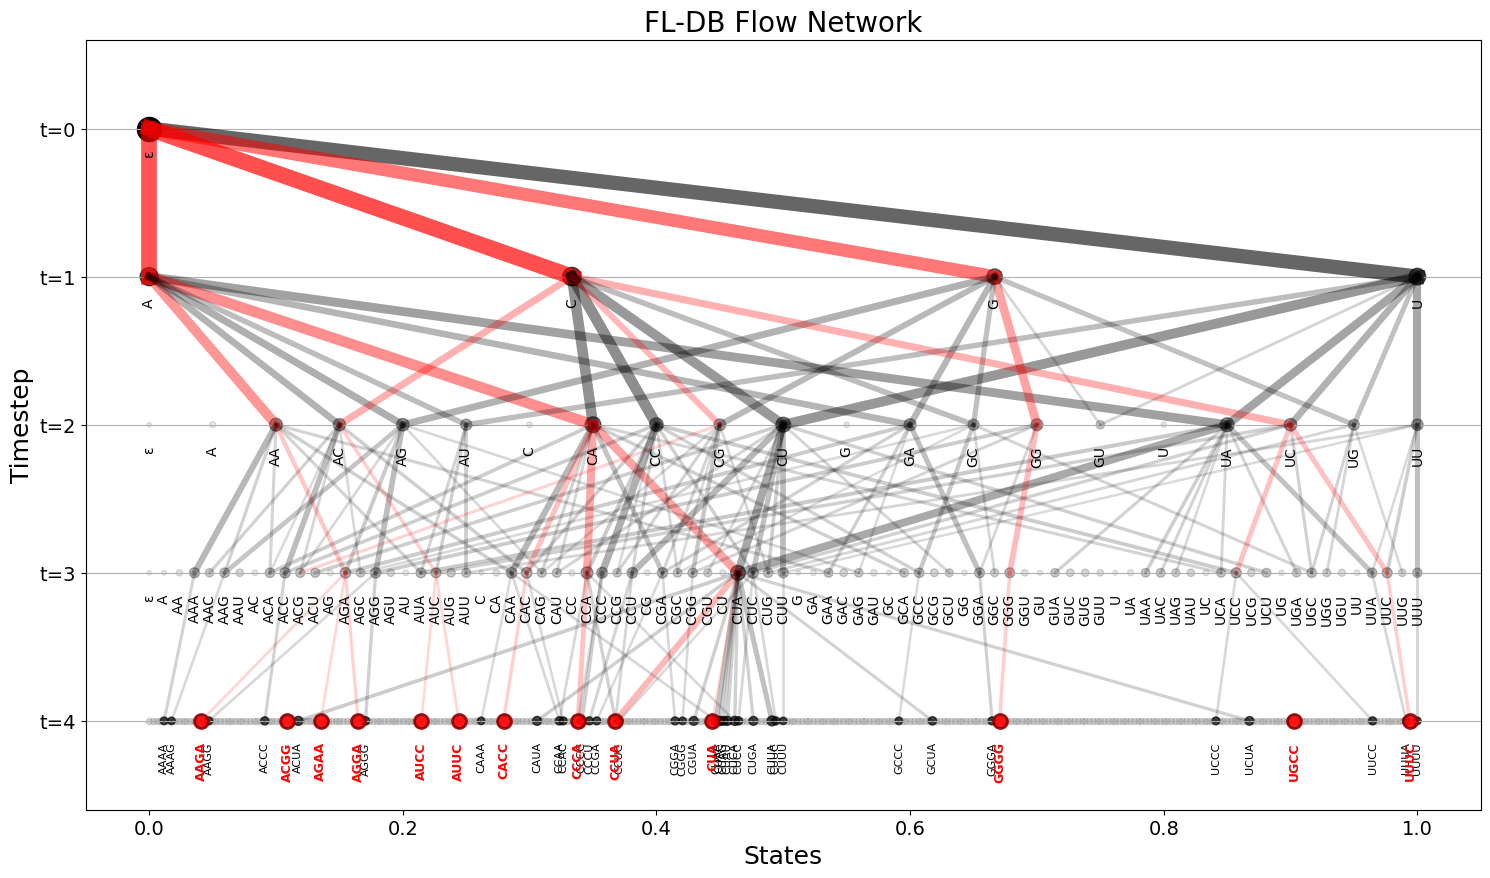

: 

In [ ]:
fig_fldb = plot_flow_network(
    result_fldb.model,
    target_sequences=target_sequences,
    edge_flow_threshold=0.3,
    show_nontarget_terminal_labels=True,
)
plt.title("FL-DB Flow Network", fontsize=20)
plt.xlabel(plt.gca().get_xlabel(), fontsize=18)
plt.ylabel(plt.gca().get_ylabel(), fontsize=18)
plt.tick_params(axis='both', labelsize=14)
fig_fldb.savefig("results/flow_network_FLDB.pdf", bbox_inches='tight')
plt.show()

## 7. Summary

| Aspect | TB | DB | FL-DB |
|--------|----|----|-------|
| Convergence | Fast | Medium | Medium |
| Parameters | Single log Z | Per-state F(s) | Per-state F(s) |
| Credit Assignment | Global | Local | Local + Rewards |